In [13]:
import numpy as np
import matplotlib.pyplot as plt


# Exercício 1

Todo número real $x \in [0,1]$ pode ser representado, ou aproximado, por meio de uma **decomposição binária**. Nessa representação, utilizamos apenas os dígitos 0 e 1.

Considerando os primeiros $D$ dígitos binários, podemos escrever

$$
x = \frac{b_1}{2} + \frac{b_2}{2^2} + \frac{b_3}{2^3} + \cdots + \frac{b_D}{2^D},
$$

em que cada $b_i \in \{0,1\}$.

Por exemplo, o número binário $0.101_2$ corresponde, na base decimal, a

$$
0.101_2
=
1\cdot\frac{1}{2}
+
0\cdot\frac{1}{2^2}
+
1\cdot\frac{1}{2^3}
=
0.625.
$$

Assim, ao gerar aleatoriamente uma sequência de zeros e uns, podemos utilizá-la como os dígitos de uma expansão binária e, dessa forma, construir números aleatórios no intervalo $[0,1]$.


Utilizando a função `np.random.choice`, gere uma sequência de tamanho $D$ composta por dígitos 0 ou 1.

1. Utilizando essa sequência e um laço `for`, construa um número aleatório entre 0 e 1 a partir de sua decomposição binária, conforme descrito acima.

2. Utilizando a função `np.arange`, repita o procedimento do item anterior **sem utilizar um laço `for`**. Faça o cálculo por meio de operações vetorizadas, utilizando a multiplicação termo a termo entre os dígitos binários e as respectivas potências de $1/2$.

3. Utilizando o procedimento vetorizado desenvolvido no item 2, gere uma amostra de tamanho $N$ de números aleatórios no intervalo $[0,1]$. Em seguida, gere outra amostra de mesmo tamanho utilizando a função `np.random.uniform`. Compare as distribuições das duas amostras por meio de histogramas e discuta se o procedimento baseado na decomposição binária produz resultados compatíveis com uma distribuição uniforme.

4. Repita o passo 3 várias vezes com diferentes valores de $D$ e comente qual o efeito de aumentar ou diminuir $D$.

In [14]:
#EXERCÍCIO 1.1
bs = np.random.choice(2,10)
print(bs)
numero = 0
for i in range(len(bs)):
  numero += bs[i]*((1/2)**(i+1))
print(numero)


[1 0 0 0 0 0 1 0 0 0]
0.5078125


In [15]:
#EXERCÍCIO 1.2
nbs = np.random.choice(2,8)

pot = ((1/2)**np.arange(1,9))
print(pot)

d = pot*nbs
d1 = np.sum(d)


[0.5        0.25       0.125      0.0625     0.03125    0.015625
 0.0078125  0.00390625]


(array([123.,  97.,  95.,  92.,  98.,  88.,  89., 109., 115.,  94.]),
 array([7.03828982e-04, 1.00563954e-01, 2.00424080e-01, 3.00284205e-01,
        4.00144330e-01, 5.00004455e-01, 5.99864581e-01, 6.99724706e-01,
        7.99584831e-01, 8.99444956e-01, 9.99305082e-01]),
 <BarContainer object of 10 artists>)

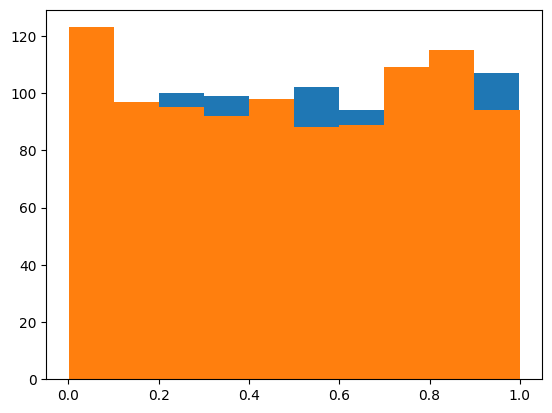

In [16]:
#EXERCÍCIO 1.3
N = 1000
amostra_gerada = []
for i in range(N):
  nbs = np.random.choice(2,N)
  pot = ((1/2)**np.arange(1,N+1))
  d = pot*nbs
  d1 = np.sum(d)
  amostra_gerada.append(d1)

plt.hist(amostra_gerada)

uni = np.random.uniform(0,1,1000)
plt.hist(uni, 10)

(array([19852., 20070., 19951., 19862., 20211., 19990., 20156., 19859.,
        20082., 19967.]),
 array([5.70637552e-06, 1.00004764e-01, 2.00003822e-01, 3.00002880e-01,
        4.00001938e-01, 5.00000996e-01, 6.00000054e-01, 6.99999112e-01,
        7.99998170e-01, 8.99997228e-01, 9.99996286e-01]),
 <BarContainer object of 10 artists>)

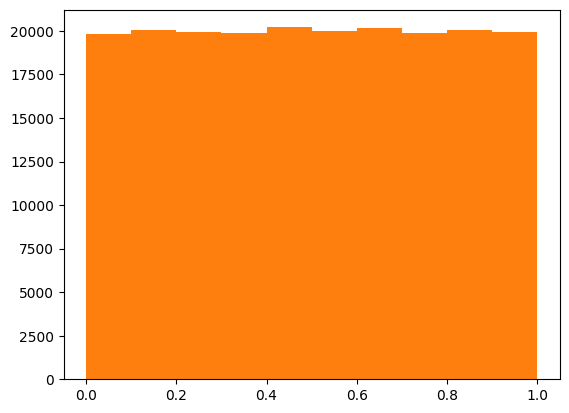

In [17]:
D = 200000
amostra_gerada = []
for i in range(N):
  nbs = np.random.choice(2,D)
  pot = ((1/2)**np.arange(1,D+1))
  d = pot*nbs
  d1 = np.sum(d)
  amostra_gerada.append(d1)

plt.hist(amostra_gerada)

uni = np.random.uniform(0,1,D)
plt.hist(uni, 10)

O aumento do valor D, causa um aumento nas casas decimais do número gerado, ou seja, proporciona um aumento na precisão na uniforme gerada.

# Exercício 2 — Simulação de variáveis aleatórias a partir da distribuição uniforme

Apesar de o exercício anterior mostrar como podemos gerar variáveis uniformes em $[0,1]$ a partir de lançamentos de moedas, a partir de agora, e ao longo do curso, assumiremos que o único mecanismo de geração de números aleatórios disponível é a geração de variáveis uniformes no intervalo $[0,1]$.

Neste exercício, vamos utilizar variáveis uniformes para simular algumas das variáveis aleatórias discretas vistas em sala.

A ideia fundamental será transformar uma variável

$$
U \sim \text{Uniforme}(0,1)
$$

em outra variável aleatória por meio de uma função apropriada.

Em todos os itens, considere uma amostra de tamanho $N$.

## 1. Gerando a amostra uniforme

Utilizando `np.random.uniform`, gere uma amostra

$$
U_1,\ldots,U_N
$$

de variáveis aleatórias independentes com distribuição uniforme em $[0,1]$.

Essa será a única fonte de aleatoriedade utilizada nos itens seguintes.

In [18]:
np.random.seed(3)

(array([2447., 2523., 2492., 2505., 2523., 2608., 2541., 2510., 2485.,
        2402., 2497., 2423., 2498., 2563., 2482., 2517., 2480., 2430.,
        2474., 2600.]),
 array([1.47356412e-05, 5.00139597e-02, 1.00013184e-01, 1.50012408e-01,
        2.00011632e-01, 2.50010856e-01, 3.00010080e-01, 3.50009304e-01,
        4.00008528e-01, 4.50007752e-01, 5.00006976e-01, 5.50006200e-01,
        6.00005424e-01, 6.50004648e-01, 7.00003872e-01, 7.50003096e-01,
        8.00002320e-01, 8.50001544e-01, 9.00000768e-01, 9.49999992e-01,
        9.99999216e-01]),
 <BarContainer object of 20 artists>)

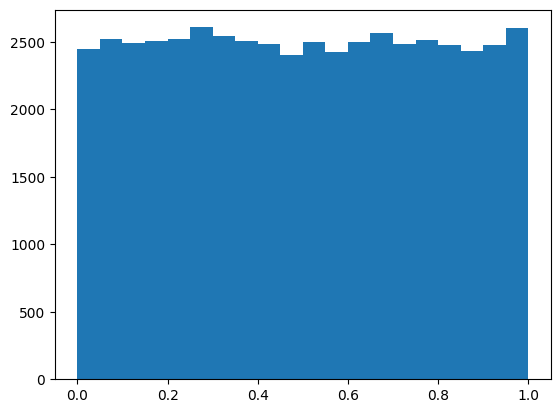

In [19]:
uniform = np.random.uniform(0,1,50000)
plt.hist(uniform,20)

## 2. Variável Bernoulli

Considere uma variável aleatória Bernoulli com parâmetro $p$, isto é,

$$
P(X=1)=p
\qquad \text{e} \qquad
P(X=0)=1-p.
$$

Utilizando a amostra uniforme gerada no item anterior:

1. Gere uma amostra Bernoulli utilizando um `for` e uma estrutura `if/else`.

2. Crie uma função `f` que transforme valores uniformes em valores `0` ou `1` de acordo com o parâmetro $p$. Em seguida, aplique diretamente essa função à amostra uniforme, isto é, `f(amostra)`.

3. Calcule a média e a variância da amostra Bernoulli obtida e compare-as com os valores teóricos

$$
\mathbb{E}[X]=p
\qquad \text{e} \qquad
\operatorname{Var}(X)=p(1-p).
$$

In [20]:
p = 0.7
bernoulli = []

for numero in uniform:
  if numero >= p:
    numero = 0
  else:
    numero = 1
  bernoulli.append(numero)


media = np.mean(bernoulli)
var = np.var(bernoulli)

print("Media amostral:",media)
print("Variância amostral:",var)

Media amostral: 0.70032
Variância amostral: 0.20987189760000002


## 3. Lançamento de um dado justo

Considere um dado justo de seis faces, de modo que

$$
P(X=k)=\frac{1}{6}, \qquad k=1,\ldots,6.
$$

Utilizando a amostra uniforme gerada no item 1:

1. Gere uma amostra de lançamentos do dado utilizando um `for` e uma estrutura `if/elif/else`.

2. Crie uma função `f` que transforme valores uniformes em valores de `1` a `6`. Em seguida, aplique diretamente a função à amostra uniforme, isto é, `f(amostra)`.

3. Você consegue encontrar uma forma mais simples de fazer essa transformação, sem utilizar `if/elif/else`? Pense no que acontece ao multiplicar um valor uniforme por 6 e considerar apenas sua parte inteira.

4. Calcule a frequência relativa de cada face e compare-a com o valor teórico $1/6$.

5. Calcule a média e a variância da amostra e compare-as com os valores teóricos: $\mathbb{E}[X], \operatorname{Var}(X).$ Você pode calcular usando a fórmula $\operatorname{Var}(X) = \mathbb{E}[X^2] - \mathbb{E}[X]^2$.

6. Repita o procedimento anterior para um dado viciado com probabilidades

$$
P(X=1)=0.05,\quad
P(X=2)=0.10,\quad
P(X=3)=0.15,
$$

$$
P(X=4)=0.20,\quad
P(X=5)=0.20,\quad
P(X=6)=0.30.
$$

Construa uma função `f` que transforme a amostra uniforme em lançamentos desse dado. Compare as frequências relativas obtidas com as probabilidades teóricas acima e compare também a média e a variância amostrais com os valores teóricos.


In [21]:
#Amostra de lançamentos
N = 10000
uniforme = np.random.uniform(size = N)
dado = []

for numero in uniform:
  if numero < 1/6:
    dado.append(1)
  elif 1/6 < numero < 2/6:
    dado.append(2)
  elif 2/6 < numero < 3/6:
    dado.append(3)
  elif 3/6 < numero < 4/6:
    dado.append(4)
  elif 4/6 < numero < 5/6:
    dado.append(5)
  else:
    dado.append(6)

In [22]:
dados = []
for numero in uniforme:
  dados.append(int(6*numero)+1)

In [23]:
#Calculo da frequência relativa
freq_absoluta = [0,0,0,0,0,0]
freq_relativa = []

for valor in dados:
  freq_absoluta[valor-1] += 1

for i in range(0,6):
  freq_relativa.append(freq_absoluta[i] / len(dados))
print("Frequência relativa amostral:",freq_relativa)

Frequência relativa amostral: [0.159, 0.1655, 0.1673, 0.1648, 0.1693, 0.1741]


O valor teorico esperado seria 1/6(aproximadamente 0,1667), ao observarmos os valores simulados vemos que há uma tendência de igualdade entre os valores observados e teoricos.

In [24]:
#Esperança e Variância da amostra
valor_esperado = sum(dados)/len(dados)
Ex2 = 0
for valor in range(1,7):
  Ex2 += (valor**2) * (freq_relativa[valor-1])
variance = Ex2 - (valor_esperado**2)

print("Esperança(Media) amostral:",valor_esperado)
print("Variância amostral:",variance)


Esperança(Media) amostral: 3.5422
Variância amostral: 2.9164191600000002


Há uma grande semelhança entre os valores calculados atraves da amostra e os valores teoricos esperados(esperança = 3,5 ; variancia = 2,9167)

In [25]:
#Dado Viciado
N = 10000
uniforme = np.random.uniform(size = N)
data = []

for numero in uniform:
  if numero < 0.05:
    data.append(1)
  elif numero < 0.15:
    data.append(2)
  elif numero < 0.30:
    data.append(3)
  elif numero < 0.50:
    data.append(4)
  elif numero < 0.70:
    data.append(5)
  else:
    data.append(6)

#Calculo da frequência relativa
f_absoluta = [0,0,0,0,0,0]
f_relativa = [0,0,0,0,0,0]

for valor in data:
  f_absoluta[valor-1] += 1
for i in range(0,6):
  f_relativa[i] = f_absoluta[i] / len(data)
print("Frequência relativa:",f_relativa)


#Esperança e Variância da amostra
esperanca = sum(data)/len(data)
esperanca2 = 0
for valor in range(1,7):
  esperanca2 += (valor**2) * (f_relativa[valor-1])
variancia = esperanca2 - (esperanca**2)
print("Esperança(Media) amostral:",esperanca)
print("Variância amostral:",variancia)


Frequência relativa: [0.04894, 0.1003, 0.15272, 0.19874, 0.19962, 0.29968]
Esperança(Media) amostral: 4.29884
Variância amostral: 2.3034146543999974


## 4. Distribuição Binomial

Podemos interpretar uma variável aleatória binomial pensando em lançamentos de uma moeda. Suponha que lançamos uma moeda $n$ vezes, de forma independente, e que a probabilidade de obter **cara** em cada lançamento seja $p$.

Se contarmos o número total de caras obtidas nesses $n$ lançamentos, esse número segue uma distribuição binomial:

$$
X \sim \mathrm{Binomial}(n,p).
$$

Assim, uma variável binomial nada mais é do que a soma de $n$ variáveis Bernoulli independentes:

$$
X = X_1 + \cdots + X_n,
\qquad
X_i \sim \mathrm{Bernoulli}(p),
$$

onde $X_i=1$ representa uma cara e $X_i=0$ representa uma coroa.

1. Utilizando o procedimento desenvolvido anteriormente para gerar variáveis Bernoulli, gere uma amostra de tamanho $N$ de variáveis com distribuição $\mathrm{Binomial}(n,p)$.

2. Calcule a média e a variância da amostra e compare-as com os valores teóricos

$$
\mathbb{E}[X]=np
\qquad \text{e} \qquad
\operatorname{Var}(X)=np(1-p).
$$

3. Gere uma segunda amostra de tamanho $N$ utilizando `np.random.binomial` com os mesmos parâmetros $n$ e $p$. Compare as duas amostras por meio de histogramas.


In [26]:
n = 30
uniforme = np.random.uniform(size = n)


(array([   3.,   63.,  402., 1323., 2469., 2835., 1923.,  773.,  178.,
          31.]),
 array([ 5.,  7.,  9., 11., 13., 15., 17., 19., 21., 23., 25.]),
 <BarContainer object of 10 artists>)

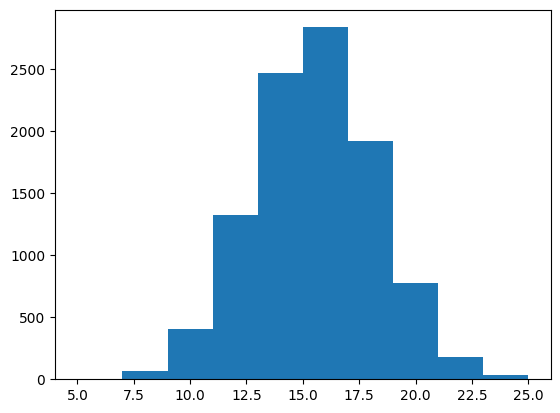

In [27]:
p = .5
N = 10000
amostra = []

for i in range(N):
  uniforme = np.random.uniform(size = n)
  binomial = np.sum(uniforme<=p)
  amostra.append(binomial)

plt.hist(amostra)

In [28]:
#Esperança e Variância
esperança = sum(amostra)/len(amostra)
variancia = 0
for valor in amostra:
    variancia += (valor-esperança) ** 2
variancia = variancia/N

teorico_esperança = n*p
teorico_var = n*p*(1-p)
print("Media amostral:", esperança)
print("Media teórica:", teorico_esperança)
print("Variância amostral:", variancia)
print("Variância teorica:", teorico_var)


Media amostral: 15.0039
Media teórica: 15.0
Variância amostral: 7.341484789999814
Variância teorica: 7.5


(array([  7.,  12.,  56., 118., 192., 242., 213.,  97.,  47.,  16.]),
 array([34., 37., 40., 43., 46., 49., 52., 55., 58., 61., 64.]),
 <BarContainer object of 10 artists>)

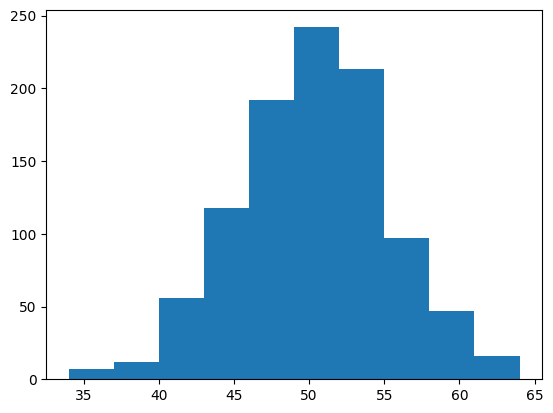

In [29]:
N = 1000
amostra = []

for i in range(N):
  amostra.append(np.random.binomial(100,0.5))
plt.hist(amostra)

## 5. Distribuição Multinomial

A distribuição multinomial é uma generalização da distribuição binomial.

Na distribuição binomial, realizamos $n$ lançamentos de uma moeda e contamos quantas vezes ocorreu um dos dois resultados possíveis. Na distribuição multinomial, fazemos a mesma ideia, mas com $k$ resultados possíveis.

Por exemplo, considere um dado de $k$ lados, em que a face $i$ aparece com probabilidade $p_i$, com

$$
p_1+\cdots+p_k=1.
$$

Após $n$ lançamentos, definimos

$$
X=(X_1,\ldots,X_k),
$$

onde $X_i$ representa o número de vezes que a face $i$ apareceu. Nesse caso,

$$
X \sim \mathrm{Multinomial}(n,p_1,\ldots,p_k),
$$

e

$$
X_1+\cdots+X_k=n.
$$

Considere agora um dado de **4 lados** com probabilidades

$$
P(X=1)=0.10,\qquad
P(X=2)=0.20,\qquad
P(X=3)=0.30,\qquad
P(X=4)=0.40.
$$

1. Utilizando o procedimento desenvolvido anteriormente, realize $n$ lançamentos desse dado e conte quantas vezes cada uma das quatro faces apareceu.

2. Repita esse experimento $N$ vezes, gerando uma amostra de tamanho $N$ de vetores com distribuição multinomial.

3. Para cada face $i$, calcule a média amostral de $X_i$ e compare-a com o valor teórico

$$
\mathbb{E}[X_i]=np_i.
$$

4. Gere uma segunda amostra utilizando `np.random.multinomial` com os mesmos parâmetros e compare os resultados obtidos pelos dois métodos.

5. Verifique que, em cada realização, a soma das contagens das $k$ faces é igual a $n$.

6. Para cada face $i$, calcule a variância amostral de $X_i$ e compare-a com

$$
\operatorname{Var}(X_i)=np_i(1-p_i).
$$

7. Escolha duas faces distintas e calcule a covariância amostral entre suas contagens. Compare-a com

$$
\operatorname{Cov}(X_i,X_j)=-np_ip_j.
$$

Interprete o sinal negativo dessa covariância.

In [30]:
#PASSO 1 E 2
k = 10
N = 1000
amostra = []

for i in range(N):
  dados = []
  uniforme = np.random.uniform(size = 1)
  for numero in uniforme:
    dados.append(np.ceil(k*numero))
  amostra.append(dados)

multinomial = np.unique(amostra,return_counts= True)
multinomial

(array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 array([103,  82, 102,  87, 115,  89,  84, 111, 109, 118]))

In [31]:
#PASSO 3
esperança_amostral = np.mean(multinomial[1],axis = 0)
esperança_teorica = N/k
print(esperança_amostral,esperança_teorica)

100.0 100.0


Agora para o caso do dado com 4 diferentes probabilidades


In [32]:
amostra_multinomial = []
N = 10000

for i in range(N):
    n = 100
    uniforme = np.random.uniform(size=n)
    bin = []
    for numero in uniforme:
        if numero < 0.10:
            bin.append(1)
        elif numero < 0.30:
            bin.append(2)
        elif numero < 0.60:
            bin.append(3)
        else:
            bin.append(4)

    contagem = [0, 0, 0, 0]
    for valor in bin:
        contagem[valor-1] += 1

    amostra_multinomial.append(contagem)



In [33]:
#Calculo da Esperança
medias = [0, 0, 0, 0]
for amostra in amostra_multinomial:
    for i in range(4):
        medias[i] += amostra[i]
for i in range(4):
    medias[i] = medias[i]/N

p = [0.10, 0.20, 0.30, 0.40]
teorico_media = []
for pi in p:
  teorico_media.append(n*pi)


print("Media amostral:", medias)
print("Media teorica:", teorico_media)

Media amostral: [10.0122, 19.9452, 29.9637, 40.0789]
Media teorica: [10.0, 20.0, 30.0, 40.0]


In [34]:
#Gerando a multinomial
amostra_np = []

for i in range(N):
    amostra_np.append(np.random.multinomial(n, p))

medias_np = [0, 0, 0, 0]
for amostra in amostra_np:
    for i in range(4):
        medias_np[i] += amostra[i]
for i in range(4):
    medias_np[i] = medias_np[i]/N

print("Media amostral numpy:", medias_np)

Media amostral numpy: [np.float64(10.0133), np.float64(20.0095), np.float64(30.0147), np.float64(39.9625)]


In [35]:
#Calculo da soma
for amostra in amostra_multinomial:
    soma = 0
    for valor in amostra:
        soma += valor

print("Valor da soma:",soma)
print(f"Valor de n: {n}")

Valor da soma: 100
Valor de n: 100


In [36]:
#Calculo da variância
variancias = [0, 0, 0, 0]

for amostra in amostra_multinomial:
    for i in range(4):
        variancias[i] += (amostra[i]-medias[i])**2
for i in range(4):
    variancias[i] = variancias[i]/N

teorico_var = []
for pi in p:
  teorico_var.append(n*pi*(1-pi))

print("Variância amostral:", variancias)
print("Variância teórica:", teorico_var)

Variância amostral: [9.186251160000213, 16.256796959999836, 21.133982310000285, 23.74047478999974]
Variância teórica: [9.0, 16.0, 21.0, 24.0]


In [37]:
#Calculo da covariância
cov = 0
for amostra in amostra_multinomial:
    cov += (amostra[0]-medias[0])*(amostra[1]-medias[1])
cov = cov/N

teorico_cov = -n*p[0]*p[1]
print("Covariância amostral:", cov)
print("Covariância teórica:", teorico_cov)

Covariância amostral: -2.0581314399999973
Covariância teórica: -2.0


A covariância entre duas faces é negativa pois o valor n atralado a soma da quantidade Xi de cada uma é fixo, ou seja, se aumentarmos a quantidade de ocorrencias de uma face, a outra face deve diminuir para manter a soma em n.